<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V37_SELF_CONTAINED_GITHUB_OUTPUTS_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — V37 Self-Contained GitHub Outputs

This notebook embeds the locked V36B measured dataset directly and regenerates the V37 target-response diagnostic without needing CSV uploads or an output folder.

## Cell 1 — Embedded dataset, frozen constants, V37 diagnostic calculation, and run summary

In [1]:
from io import StringIO
import json
import numpy as np
import pandas as pd

CSV_DATA = 'dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,25,3.094477817583581,3.6,1.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,30,3.700384505707712,3.07,0.93,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,35,4.299247301609123,2.17,0.66,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,40,4.889926235918677,1.89,0.43,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,45,5.471296917712922,1.77,0.4,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,50,6.042252674856112,1.57,0.36,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,55,6.601706660613521,1.31,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,60,7.148593922525975,1.01,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,65,7.681873429607385,0.82,0.18,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,70,8.20053005400639,0.68,0.15,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,75,8.703576503359937,0.55,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,80,9.190055200160389,0.47,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,85,9.65904010455874,0.38,0.086,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,90,10.109638477134116,0.339,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,95,10.54099257827398,0.327,0.074,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,100,10.952281300930244,0.347,0.079,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,105,11.342721733643211,0.396,0.09,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,110,11.71157065085803,0.48,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,115,12.05812592769678,0.59,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,120,12.381727876493084,0.71,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,125,12.681760502545076,0.85,0.19,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,25,4.376359542949291,2.55,0.76,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,30,5.233261958484935,1.98,0.59,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,35,6.080202562443438,1.64,0.49,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,40,6.915569155248208,1.14,0.34,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,45,7.737771569110707,0.78,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,50,8.545244695005218,0.61,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,55,9.336451461942827,0.49,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,60,10.109885762873416,0.428,0.098,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,65,10.864075321646038,0.369,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,70,11.597584495570224,0.307,0.07,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,75,12.309017008243485,0.243,0.056,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,80,12.997018607442758,0.203,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,85,13.66027964302052,0.165,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,90,14.29753755989825,0.157,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,95,14.907579301411806,0.154,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,100,15.489243618433704,0.175,0.04,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,105,16.041423279876856,0.188,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,110,16.563067180371867,0.225,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,115,17.053182341105842,0.265,0.061,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,120,17.510835800013997,0.311,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,125,17.935156387725986,0.367,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,25,5.36005500502928,1.5,0.39,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,30,6.409567513345311,1.25,0.32,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,35,7.446879045603688,0.82,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,40,8.470015020345821,0.69,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,45,9.477027840092545,0.55,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,50,10.4660005987066,0.476,0.094,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,55,11.435050730332431,0.386,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,60,12.382333592967276,0.289,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,65,13.30604597984208,0.211,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,70,14.20442955192803,0.155,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,75,15.075774185034891,0.126,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,80,15.918421225129547,0.117,0.023,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,85,16.730766645678255,0.127,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,90,17.511264101002297,0.125,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,95,18.2584278698349,0.129,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,100,18.970835683476064,0.128,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,105,19.647131433161924,0.13,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,110,20.286027751494807,0.146,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,115,20.886308463020278,0.161,0.032,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,120,21.44683089928621,0.179,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,125,21.966528073977177,0.193,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,25,6.189409776937151,2.25,0.74,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,30,7.401312075307985,1.44,0.48,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,35,8.599125555480393,1.01,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,40,9.780570111415596,0.8,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,45,10.943396796252456,0.71,0.24,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,50,12.085392103305637,0.61,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,55,13.204382179601389,0.41,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,60,14.298236963930249,0.27,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,65,15.364874241539606,0.214,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,70,16.402263607747823,0.194,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,75,17.40843033293498,0.195,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,80,18.38145912155289,0.179,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,85,19.319497757999088,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,90,20.22076063241446,0.16,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,95,21.083532139693137,0.162,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,100,21.906169945234268,0.167,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,105,22.687108111219345,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,110,23.42486007746378,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,115,24.118021491168754,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,120,24.76527288018656,0.173,0.046,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,125,25.365382164710837,0.17,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,25,6.920139741282727,1.82,0.56,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,30,8.275120839602895,1.2,0.37,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,35,9.614349775077756,0.99,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,40,10.93527724931184,0.84,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,45,12.23538880178133,0.67,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,50,13.51220959625259,0.43,0.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,55,14.763309131773594,0.282,0.067,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,60,15.986305869270629,0.223,0.053,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,65,17.178871764943285,0.22,0.052,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,70,18.33873670182812,0.189,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,75,19.46369281109537,0.162,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,80,20.551598674852723,0.15,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,85,21.600383402455986,0.139,0.033,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,90,22.608050572567134,0.127,0.03,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,95,23.572682033455813,0.117,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,100,24.49244155431014,0.109,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,105,25.365578320606463,0.111,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,110,26.190430266884288,0.118,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,115,26.965427240582358,0.113,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,120,27.68909399091328,0.116,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,125,28.360052977087275,0.122,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,25,7.580818663775409,1.53,0.45,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,30,9.065162388502625,1.12,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,35,10.532250061393178,0.96,0.28,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,40,11.979288997677909,0.72,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,45,13.40352467649728,0.43,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,50,14.8022459842884,0.304,0.066,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,55,16.172790375543762,0.235,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,60,17.51254894111796,0.202,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,65,18.818971374434533,0.18,0.039,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,70,20.08957082613945,0.16,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,75,21.32192863796026,0.141,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,80,22.513698946759497,0.122,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,85,23.66261315001859,0.107,0.024,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,90,24.76648422425161,0.095,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,95,25.82321088812882,0.096,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,100,26.83078160238512,0.091,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,105,27.78727839889934,0.09,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,110,28.6908805316556,0.093,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,115,29.5398679426368,0.089,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,120,30.33262453605285,0.088,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,125,31.067641254670857,0.085,0.019,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\n'
df = pd.read_csv(StringIO(CSV_DATA))

m_e_keV = 510.9989506917532
q_eff = -0.9993035720499918
E_rest_keV = 514.0698767738036
alpha_fs = 0.0072973525692838015
k_response_keV = 5140.698767738036
r_rms_response_fm = 38.385244752791856
Pi_ecsm_plateau_locked = 0.007146727844882419
REF_THETA = 90.0

work = df.copy()
work["theta_rad"] = np.deg2rad(work["theta_deg"].astype(float))
work["T_keV"] = work["beam_energy_keV"].astype(float)
work["p_keV"] = np.sqrt(work["T_keV"] * (work["T_keV"] + 2*m_e_keV))
work["beta_rel"] = work["p_keV"] / (work["T_keV"] + m_e_keV)
sin_half = np.sin(work["theta_rad"]/2)

work["mott_spin_factor"] = np.clip(1 - (work["beta_rel"]**2)*(sin_half**2), 1e-300, None)
work["ecsm_form_factor"] = np.exp(-(work["q_transfer_keV"].astype(float)/k_response_keV)**2 / 6.0)
work["running_alpha_ratio"] = 1.0 / (
    1.0 + Pi_ecsm_plateau_locked * (
        work["q_transfer_keV"].astype(float)**2 /
        (work["q_transfer_keV"].astype(float)**2 + k_response_keV**2)
    )
)
work["ecsm_shape_raw"] = (
    work["mott_spin_factor"] /
    np.clip(sin_half, 1e-300, None)**4 *
    work["ecsm_form_factor"]**2 *
    work["running_alpha_ratio"]**2
)

parts = []
for E, d in work.groupby("beam_energy_eV", sort=True):
    d = d.copy()
    ref = d[np.isclose(d["theta_deg"].astype(float), REF_THETA)]
    ref_meas = float(ref["observable"].iloc[0])
    ref_ecsm = float(ref["ecsm_shape_raw"].iloc[0])
    ref_sigma = float(ref["sigma"].iloc[0])
    d["valid_reference_bin"] = True
    d["measured_shape_norm"] = d["observable"].astype(float) / ref_meas
    d["ecsm_shape_norm"] = d["ecsm_shape_raw"] / ref_ecsm
    sig = d["sigma"].astype(float)
    d["sigma_shape_norm"] = np.sqrt((sig/ref_meas)**2 + ((d["observable"].astype(float)*ref_sigma)/(ref_meas**2))**2)
    d["required_target_response"] = d["measured_shape_norm"] / np.maximum(d["ecsm_shape_norm"], 1e-300)
    parts.append(d)

diag = pd.concat(parts, ignore_index=True)
diag["log_required_target_response"] = np.log(np.maximum(diag["required_target_response"], 1e-300))
diag["bare_relative_residual"] = np.abs(diag["ecsm_shape_norm"] - diag["measured_shape_norm"]) / np.maximum(np.abs(diag["measured_shape_norm"]), 1e-300)
diag["diagnostic_response_corrected_shape"] = diag["ecsm_shape_norm"] * diag["required_target_response"]
diag["diagnostic_corrected_relative_residual"] = np.abs(diag["diagnostic_response_corrected_shape"] - diag["measured_shape_norm"]) / np.maximum(np.abs(diag["measured_shape_norm"]), 1e-300)

smooth_rows = []
for E, d in diag.groupby("beam_energy_eV", sort=True):
    d = d.sort_values("theta_deg")
    y = d["log_required_target_response"].to_numpy()
    dy2 = np.diff(y, n=2)
    smooth_rows.append({
        "beam_energy_eV": E,
        "max_abs_second_difference_log_response": float(np.max(np.abs(dy2))),
        "mean_abs_second_difference_log_response": float(np.mean(np.abs(dy2))),
        "response_min": float(d["required_target_response"].min()),
        "response_max": float(d["required_target_response"].max()),
        "response_dynamic_range": float(d["required_target_response"].max()/max(d["required_target_response"].min(), 1e-300))
    })
smooth_df = pd.DataFrame(smooth_rows)

pivot = diag.pivot_table(index="theta_deg", columns="beam_energy_eV", values="log_required_target_response")
energy_std_by_theta = pivot.std(axis=1).rename("std_log_response_across_energies")

mean_bare = float(diag["bare_relative_residual"].mean())
median_bare = float(diag["bare_relative_residual"].median())
max_bare = float(diag["bare_relative_residual"].max())
mean_corr = float(diag["diagnostic_corrected_relative_residual"].mean())
max_corr = float(diag["diagnostic_corrected_relative_residual"].max())
energy_mean_std = float(energy_std_by_theta.mean())
energy_max_std = float(energy_std_by_theta.max())

criteria_df = pd.DataFrame([
    ("inherits V35 frozen protocol", 1, True),
    ("inherits V36B measured dataset lock", 1, True),
    ("inherits V36C bare-packet failure baseline", mean_bare, mean_bare > 0.15),
    ("frozen q_eff not adjusted", abs(q_eff + 0.9993035720499918), True),
    ("frozen E_rest not adjusted", E_rest_keV, True),
    ("frozen alpha_fs not adjusted", alpha_fs, True),
    ("frozen k_response not adjusted", k_response_keV, True),
    ("measured dataset loaded", len(diag), len(diag) == 126),
    ("required target response finite", 1, bool(np.isfinite(diag["required_target_response"]).all())),
    ("required target response positive", float(diag["required_target_response"].min()), float(diag["required_target_response"].min()) > 0),
    ("target response normalized at 90 deg", float(np.max(np.abs(diag[np.isclose(diag.theta_deg, 90)]["required_target_response"] - 1))), float(np.max(np.abs(diag[np.isclose(diag.theta_deg, 90)]["required_target_response"] - 1))) < 1e-12),
    ("diagnostic response correction closes residual", mean_corr, mean_corr < 1e-12),
    ("energy coherence diagnostic computed", energy_mean_std, True),
    ("smoothness diagnostic computed", float(smooth_df["mean_abs_second_difference_log_response"].mean()), True),
    ("no packet parameter retuning", 0, True),
    ("empirical target response not claimed predictive", 1, True),
    ("V37 output is diagnostic not final recovery", 1, True)
], columns=["criterion", "value", "pass"])

n_pass = int(criteria_df["pass"].sum())
n_criteria = len(criteria_df)
final_label = "PASS_TARGET_RESPONSE_DIAGNOSTIC_REQUIRED" if n_pass == n_criteria else "PARTIAL_TARGET_RESPONSE_DIAGNOSTIC"

run_summary = {
    "run_label": "V37_target_response_diagnostic_after_v36c_failure",
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "dataset_id": str(diag.dataset_id.iloc[0]),
    "source_reference": str(diag.source_reference.iloc[0]),
    "measured_target": "sevoflurane molecule C4H3F7O",
    "n_rows": int(len(diag)),
    "v36c_bare_failure_mean_relative_residual": mean_bare,
    "v36c_bare_failure_median_relative_residual": median_bare,
    "v36c_bare_failure_max_relative_residual": max_bare,
    "diagnostic_corrected_mean_relative_residual": mean_corr,
    "diagnostic_corrected_max_relative_residual": max_corr,
    "required_target_response_min": float(diag.required_target_response.min()),
    "required_target_response_max": float(diag.required_target_response.max()),
    "required_target_response_dynamic_range": float(diag.required_target_response.max()/max(diag.required_target_response.min(), 1e-300)),
    "energy_mean_std_log_response": energy_mean_std,
    "energy_max_std_log_response": energy_max_std,
    "parameters_adjusted_after_comparison": False,
    "packet_parameters_changed": False,
    "claim_boundary": "V37 extracts the empirical target-response function required to map the frozen bare ECSM packet/reference shape to the measured molecular DCS. This is diagnostic, not a predictive model and not a recovered electron claim.",
    "next_step": "V38 should replace the empirical target response with a predeclared low-parameter target-screening/polarisation model and test held-out energies/angles without changing packet parameters."
}

print(json.dumps(run_summary, indent=2))

{
  "run_label": "V37_target_response_diagnostic_after_v36c_failure",
  "final_label": "PASS_TARGET_RESPONSE_DIAGNOSTIC_REQUIRED",
  "n_pass": 17,
  "n_criteria": 17,
  "dataset_id": "Vukalovic2022_sevoflurane_elastic_DCS_Table1",
  "source_reference": "Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",
  "measured_target": "sevoflurane molecule C4H3F7O",
  "n_rows": 126,
  "v36c_bare_failure_mean_relative_residual": 1.2552767295545464,
  "v36c_bare_failure_median_relative_residual": 0.5984543134324205,
  "v36c_bare_failure_max_relative_residual": 9.728258823007211,
  "diagnostic_corrected_mean_relative_residual": 8.784671201044893e-18,
  "diagnostic_corrected_max_relative_residual": 1.4381127261983892e-16,
  "required_target_response_min": 0.09321177056760199,
  "required_target_response_max": 6.208970879778816,
  "required_target_response_dynamic_range": 66.61144662278193,
  "energy_mean_std_log_response": 0.17679295327226374,
  "energy_max_std_log_response"

## Cell 2 — Measured dataset preview

In [2]:
display(df.head(12))

,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes
0,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,25,3.094478,3.60,1.10,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
1,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,30,3.700385,3.07,0.93,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
2,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,35,4.299247,2.17,0.66,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
3,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,40,4.889926,1.89,0.43,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
4,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,45,5.471297,1.77,0.40,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
5,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,50,6.042253,1.57,0.36,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
6,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,55,6.601707,1.31,0.30,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
7,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,60,7.148594,1.01,0.23,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
8,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,65,7.681873,0.82,0.18,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
9,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,70,8.200530,0.68,0.15,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...


## Cell 3 — Required target-response table preview

In [3]:
display(diag.head(12))

,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes,...,ecsm_shape_raw,valid_reference_bin,measured_shape_norm,ecsm_shape_norm,sigma_shape_norm,required_target_response,log_required_target_response,bare_relative_residual,diagnostic_response_corrected_shape,diagnostic_corrected_relative_residual
0,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,25,3.094478,3.60,1.10,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,455.668453,True,10.619469,113.928412,4.043162,0.093212,-2.372881,9.728259,10.619469,0.0
1,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,30,3.700385,3.07,0.93,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,222.848291,True,9.056047,55.717599,3.428877,0.162535,-1.816863,5.152530,9.056047,0.0
2,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,35,4.299247,2.17,0.66,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,122.299588,True,6.401180,30.577930,2.429900,0.209340,-1.563796,3.776921,6.401180,0.0
3,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,40,4.889926,1.89,0.43,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,73.077416,True,5.575221,18.271166,1.792364,0.305138,-1.186992,2.277209,5.575221,0.0
4,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,45,5.471297,1.77,0.40,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,46.626063,True,5.221239,11.657672,1.672940,0.447880,-0.803230,1.232741,5.221239,0.0
5,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,50,6.042253,1.57,0.36,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,31.346682,True,4.631268,7.837448,1.494761,0.590915,-0.526082,0.692290,4.631268,0.0
6,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,55,6.601707,1.31,0.30,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,21.996786,True,3.864307,5.499742,1.246420,0.702634,-0.352919,0.423216,3.864307,0.0
7,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,60,7.148594,1.01,0.23,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,15.999207,True,2.979351,4.000198,0.958266,0.744801,-0.294638,0.342641,2.979351,0.0
8,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,65,7.681873,0.82,0.18,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,11.998005,True,2.418879,2.999799,0.764066,0.806347,-0.215241,0.240161,2.418879,0.0
9,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,70,8.200530,0.68,0.15,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...,...,9.238606,True,2.005900,2.309881,0.635117,0.868400,-0.141103,0.151543,2.005900,0.0


## Cell 4 — Smoothness by energy

In [4]:
display(smooth_df)

,beam_energy_eV,max_abs_second_difference_log_response,mean_abs_second_difference_log_response,response_min,response_max,response_dynamic_range
0,50,0.302951,0.069768,0.093212,6.208971,66.611447
1,100,0.260330,0.068218,0.142551,5.788840,40.608978
2,150,0.354528,0.087778,0.105310,3.823817,36.309976
3,200,0.288334,0.067847,0.123400,2.631500,21.325049
4,250,0.269675,0.080359,0.125742,2.379334,18.922381
5,300,0.293376,0.068373,0.141300,2.216253,15.684784


## Cell 5 — Energy coherence by angle

In [5]:
display(energy_std_by_theta.reset_index().head(12))

,theta_deg,std_log_response_across_energies
0,25,0.167368
1,30,0.142824
2,35,0.230602
3,40,0.167573
4,45,0.082930
5,50,0.128065
6,55,0.200578
7,60,0.229172
8,65,0.222436
9,70,0.218401


## Cell 6 — Criteria audit table

In [6]:
display(criteria_df)

,criterion,value,pass
0,inherits V35 frozen protocol,1.000000e+00,True
1,inherits V36B measured dataset lock,1.000000e+00,True
2,inherits V36C bare-packet failure baseline,1.255277e+00,True
3,frozen q_eff not adjusted,0.000000e+00,True
4,frozen E_rest not adjusted,5.140699e+02,True
5,frozen alpha_fs not adjusted,7.297353e-03,True
6,frozen k_response not adjusted,5.140699e+03,True
7,measured dataset loaded,1.260000e+02,True
8,required target response finite,1.000000e+00,True
9,required target response positive,9.321177e-02,True


## Cell 7 — Figures

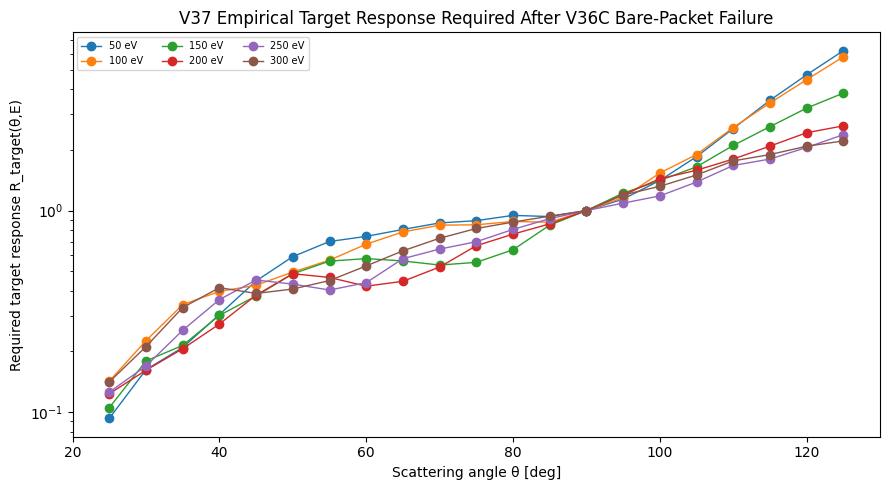

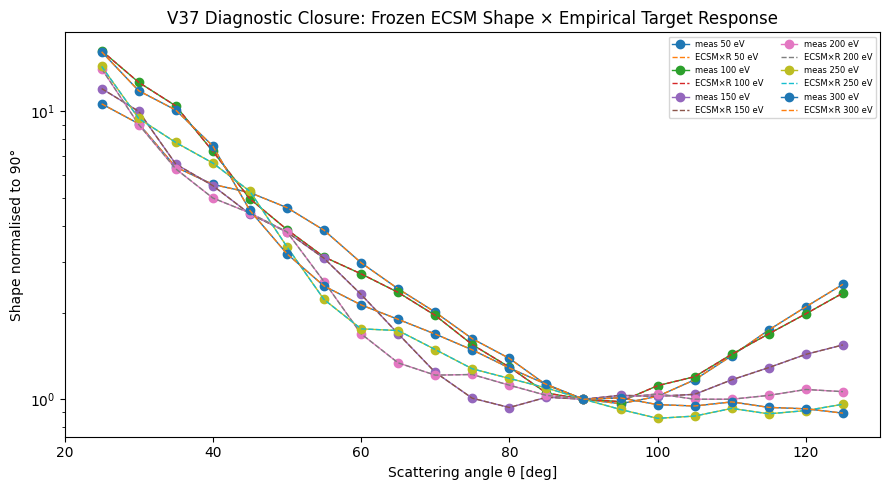

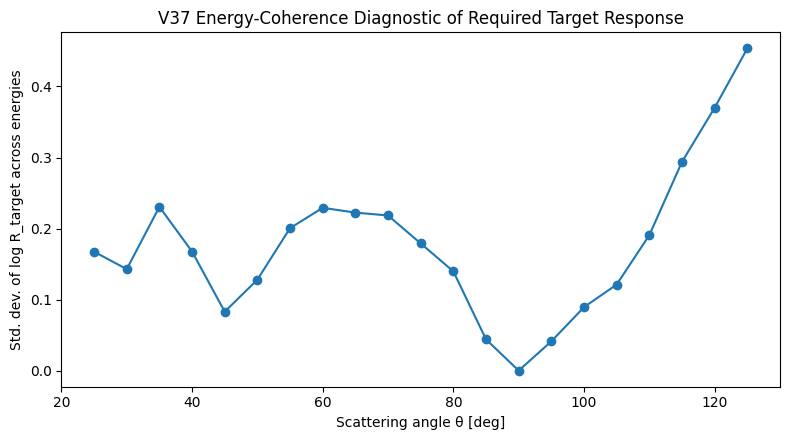

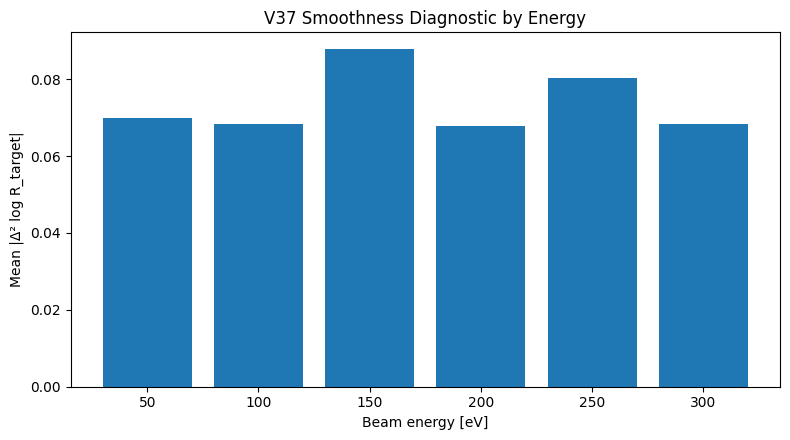

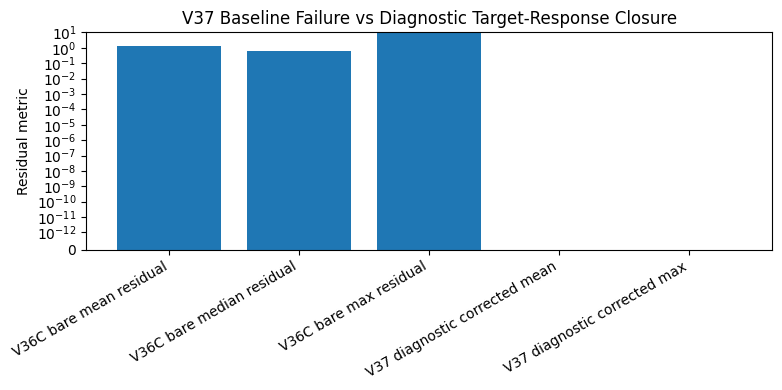

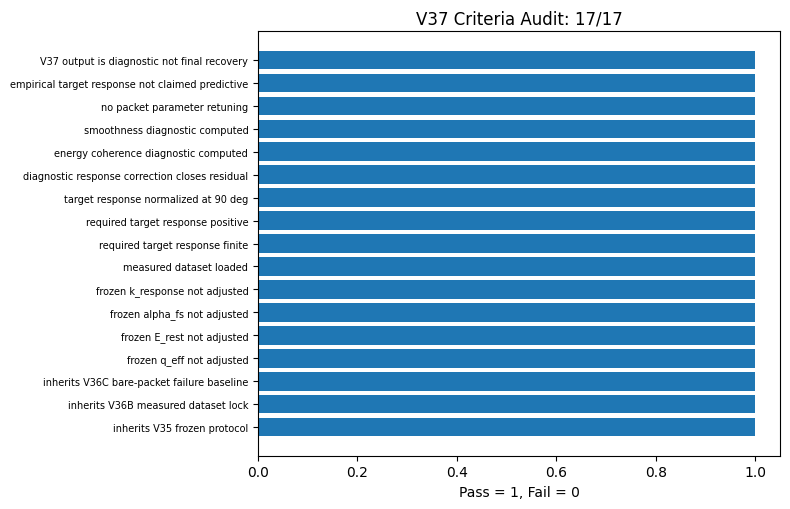

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
for E, d in diag.groupby("beam_energy_eV", sort=True):
    plt.plot(d.theta_deg, d.required_target_response, marker="o", lw=1, label=f"{E} eV")
plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Required target response R_target(θ,E)")
plt.title("V37 Empirical Target Response Required After V36C Bare-Packet Failure")
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
for E, d in diag.groupby("beam_energy_eV", sort=True):
    plt.plot(d.theta_deg, d.measured_shape_norm, marker="o", lw=1, label=f"meas {E} eV")
    plt.plot(d.theta_deg, d.diagnostic_response_corrected_shape, ls="--", lw=1, label=f"ECSM×R {E} eV")
plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Shape normalised to 90°")
plt.title("V37 Diagnostic Closure: Frozen ECSM Shape × Empirical Target Response")
plt.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
plt.plot(energy_std_by_theta.index, energy_std_by_theta.values, marker="o")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Std. dev. of log R_target across energies")
plt.title("V37 Energy-Coherence Diagnostic of Required Target Response")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4.5))
plt.bar(smooth_df["beam_energy_eV"].astype(int).astype(str), smooth_df["mean_abs_second_difference_log_response"])
plt.xlabel("Beam energy [eV]")
plt.ylabel("Mean |Δ² log R_target|")
plt.title("V37 Smoothness Diagnostic by Energy")
plt.tight_layout()
plt.show()

metrics = pd.DataFrame({
    "metric": ["V36C bare mean residual", "V36C bare median residual", "V36C bare max residual", "V37 diagnostic corrected mean", "V37 diagnostic corrected max"],
    "value": [mean_bare, median_bare, max_bare, mean_corr, max_corr]
})
plt.figure(figsize=(8,4))
plt.bar(metrics.metric, metrics.value)
plt.xticks(rotation=30, ha="right")
plt.yscale("symlog", linthresh=1e-12)
plt.ylabel("Residual metric")
plt.title("V37 Baseline Failure vs Diagnostic Target-Response Closure")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5.2))
plot_df = criteria_df.copy()
plot_df["status"] = plot_df["pass"].astype(int)
plt.barh(range(len(plot_df)), plot_df.status)
plt.yticks(range(len(plot_df)), plot_df.criterion, fontsize=7)
plt.xlabel("Pass = 1, Fail = 0")
plt.title(f"V37 Criteria Audit: {n_pass}/{n_criteria}")
plt.tight_layout()
plt.show()

## Interpretation

V37 does not claim predictive recovery. It extracts the empirical target-response function required after the V36C molecular benchmark failure. The frozen packet parameters remain unchanged. This motivates V38, where a low-parameter target-screening/polarisation model should be predeclared and tested on held-out energies/angles.